In [1]:
import pandas as pd
import os
import numpy as np
import cv2

# Packages for visuals
import matplotlib.pyplot as plt


# Allows charts to appear in the notebook
%matplotlib inline


import pickle

In [2]:
dir =  'C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf'

In [3]:
categories = ['Healthy','Not Healthy']
data = []

for category in categories:
    path = os.path.join(dir,category) #'C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf'
    label = categories.index(category) 
    for img in os.listdir(path):
        imgpath = os.path.join(path,img) #'C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf'
        leaf_img = cv2.imread(imgpath,0)
        try:
            leaf_img = cv2.resize(leaf_img,(50,50))
            image = np.array(leaf_img).flatten()
            data.append([image,label])
        except Exception as e:
            pass
print(len(data))

200


In [4]:
data

[[array([236, 238, 239, ..., 144, 147, 148], shape=(2500,), dtype=uint8), 0],
 [array([195, 202, 207, ..., 244, 244, 245], shape=(2500,), dtype=uint8), 0],
 [array([226, 226, 227, ..., 217, 211, 209], shape=(2500,), dtype=uint8), 0],
 [array([210, 211, 213, ..., 236, 237, 236], shape=(2500,), dtype=uint8), 0],
 [array([220, 219, 220, ..., 235, 235, 235], shape=(2500,), dtype=uint8), 0],
 [array([188, 192, 195, ..., 221, 221, 222], shape=(2500,), dtype=uint8), 0],
 [array([243, 243, 243, ..., 245, 242, 242], shape=(2500,), dtype=uint8), 0],
 [array([242, 245, 246, ..., 173, 174, 174], shape=(2500,), dtype=uint8), 0],
 [array([210, 211, 213, ..., 165, 164, 162], shape=(2500,), dtype=uint8), 0],
 [array([241, 243, 244, ..., 195, 194, 193], shape=(2500,), dtype=uint8), 0],
 [array([224, 225, 228, ..., 191, 189, 188], shape=(2500,), dtype=uint8), 0],
 [array([213, 215, 216, ..., 158, 158, 156], shape=(2500,), dtype=uint8), 0],
 [array([251, 252, 253, ..., 180, 181, 183], shape=(2500,), dtyp

In [5]:
import pickle

pick_in = open('MANGOLEAF_DATASET.pickle','wb') #create a pickle file and set to write mode
pickle.dump(data,pick_in)
pick_in.close()

In [6]:
import pickle
pick_out = open('MANGOLEAF_DATASET.pickle','rb') #read a pickle file and set to write mode
mydata = pickle.load(pick_out)
pick_out.close()

In [7]:
mydata

[[array([236, 238, 239, ..., 144, 147, 148], shape=(2500,), dtype=uint8), 0],
 [array([195, 202, 207, ..., 244, 244, 245], shape=(2500,), dtype=uint8), 0],
 [array([226, 226, 227, ..., 217, 211, 209], shape=(2500,), dtype=uint8), 0],
 [array([210, 211, 213, ..., 236, 237, 236], shape=(2500,), dtype=uint8), 0],
 [array([220, 219, 220, ..., 235, 235, 235], shape=(2500,), dtype=uint8), 0],
 [array([188, 192, 195, ..., 221, 221, 222], shape=(2500,), dtype=uint8), 0],
 [array([243, 243, 243, ..., 245, 242, 242], shape=(2500,), dtype=uint8), 0],
 [array([242, 245, 246, ..., 173, 174, 174], shape=(2500,), dtype=uint8), 0],
 [array([210, 211, 213, ..., 165, 164, 162], shape=(2500,), dtype=uint8), 0],
 [array([241, 243, 244, ..., 195, 194, 193], shape=(2500,), dtype=uint8), 0],
 [array([224, 225, 228, ..., 191, 189, 188], shape=(2500,), dtype=uint8), 0],
 [array([213, 215, 216, ..., 158, 158, 156], shape=(2500,), dtype=uint8), 0],
 [array([251, 252, 253, ..., 180, 181, 183], shape=(2500,), dtyp

In [8]:
import random

random.shuffle(mydata)
features = []
labels = []

for feature, label in mydata:
    features.append(feature)
    labels.append(label)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC #support vector classifier

xtrain, xtest, ytrain, ytest = train_test_split(features,labels,test_size=0.20)
model = SVC(C=1, kernel='poly',gamma='auto')
model.fit(xtrain,ytrain)

,C,1
,kernel,'poly'
,degree,3
,gamma,'auto'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Accuracy:  0.825
Prediction is:  Healthy


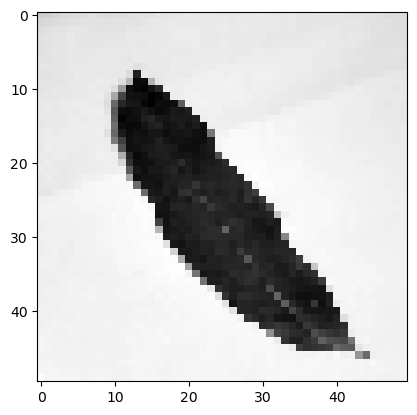

In [10]:
categories = ['Healthy','Not Healthy']
prediction = model.predict(xtest)
accuracy = model.score(xtest,ytest)

print('Accuracy: ',accuracy)
print('Prediction is: ',categories[prediction[0]])

leaf = xtest[min(0, len(xtest)-1)].reshape(50,50)
plt.imshow(leaf,cmap='gray')
plt.show()

Number of misclassified images: 7


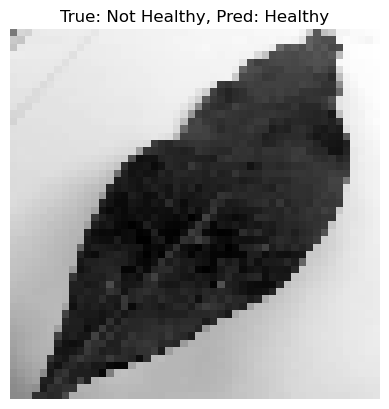

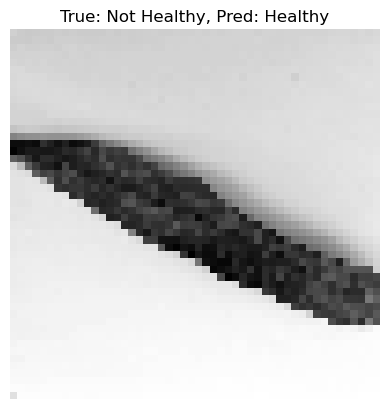

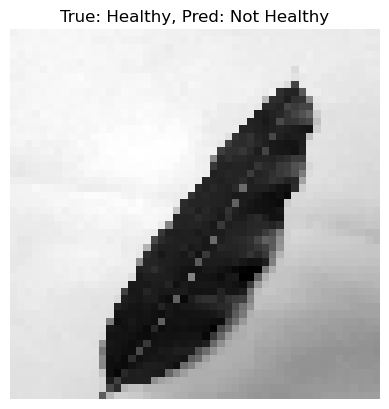

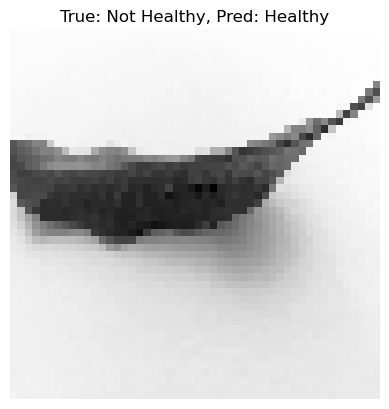

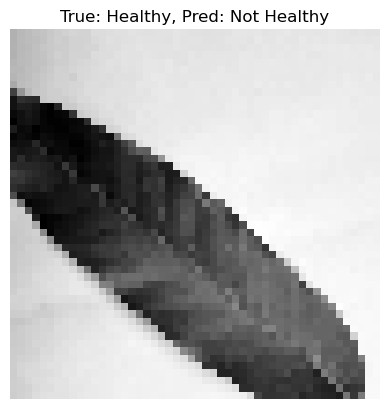

In [11]:
# Highlight misclassified images
misclassified_indices = [i for i, (pred, true) in enumerate(zip(prediction, ytest)) if pred != true]
print(f"Number of misclassified images: {len(misclassified_indices)}")
for idx in misclassified_indices[:5]:  # Show up to 5 misclassified samples
    img = np.array(xtest[idx]).reshape(50, 50)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {categories[ytest[idx]]}, Pred: {categories[prediction[idx]]}")
    plt.axis('off')
    plt.show()

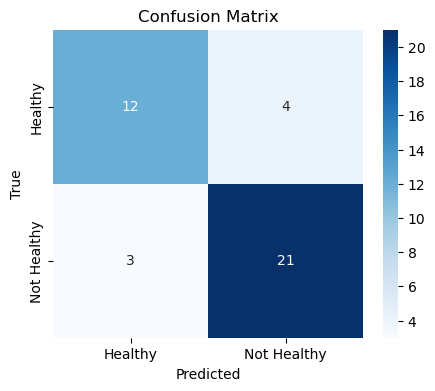

              precision    recall  f1-score   support

     Healthy       0.80      0.75      0.77        16
 Not Healthy       0.84      0.88      0.86        24

    accuracy                           0.82        40
   macro avg       0.82      0.81      0.82        40
weighted avg       0.82      0.82      0.82        40



In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(ytest, prediction)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(ytest, prediction, target_names=categories))

In [13]:
len(prediction)

40

Prediction is:  Not Healthy


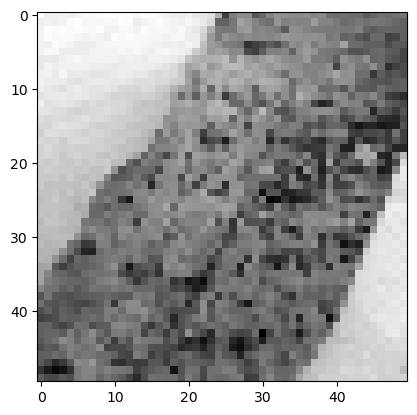

In [14]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (1).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Healthy


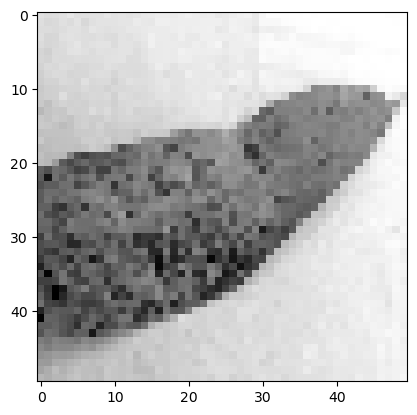

In [15]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (2).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Healthy


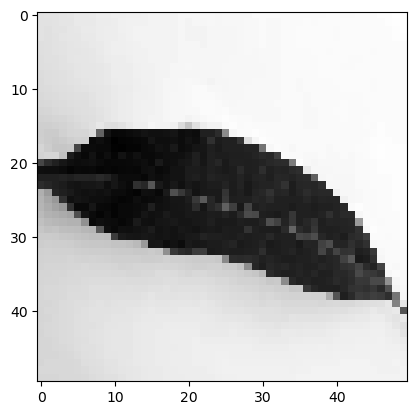

In [16]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (3).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Healthy


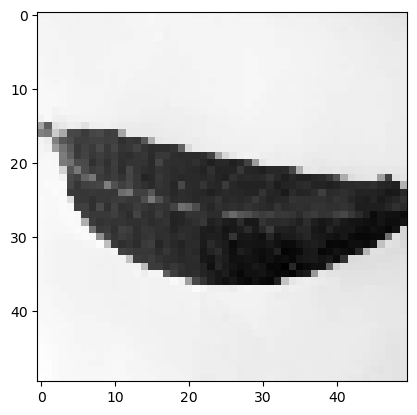

In [17]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (4).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Healthy


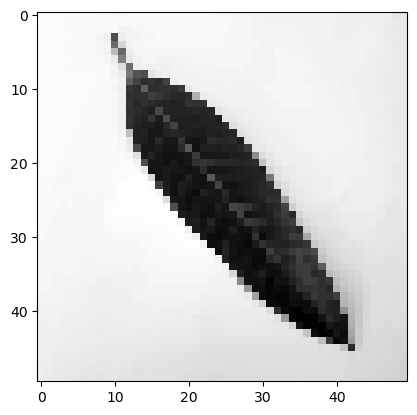

In [18]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (5).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Not Healthy


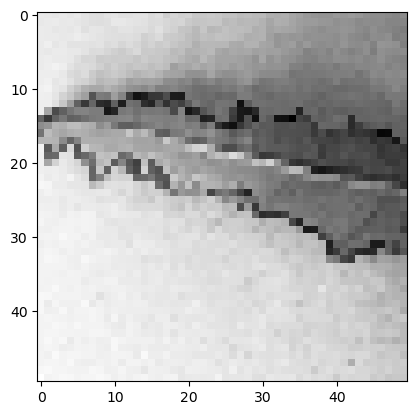

In [19]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (6).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Not Healthy


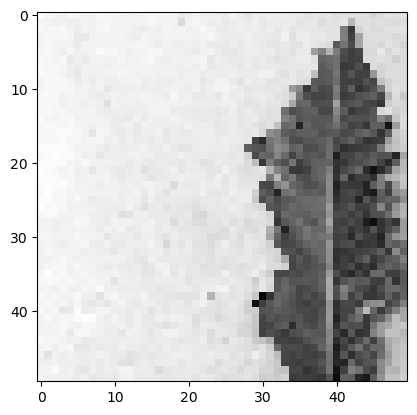

In [20]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (7).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Healthy


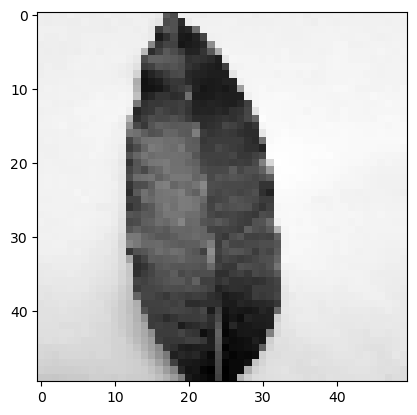

In [26]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (8).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Healthy


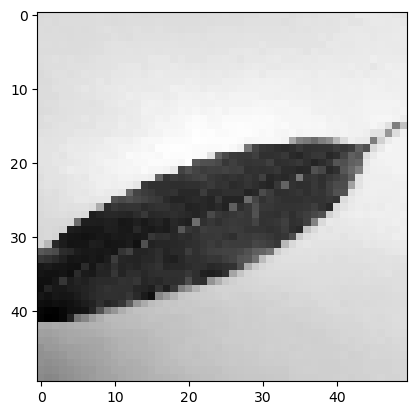

In [27]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (9).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Healthy


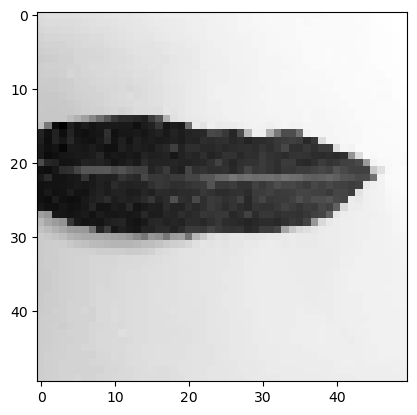

In [28]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (10).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Healthy


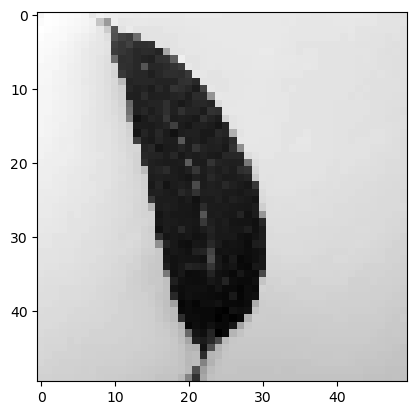

In [29]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (11).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Healthy


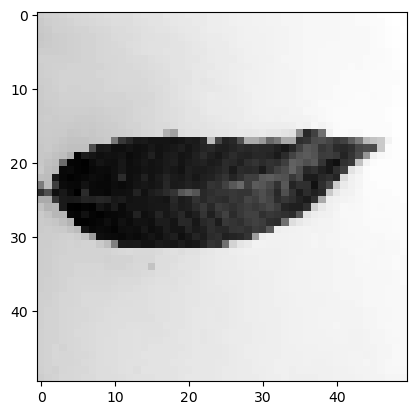

In [30]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (12).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Not Healthy


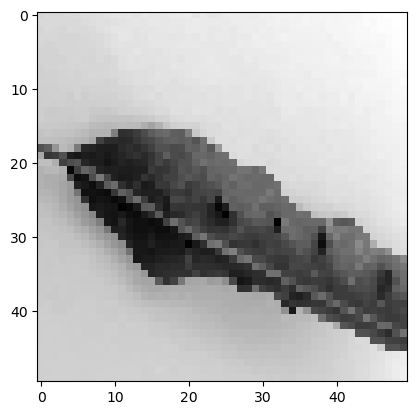

In [37]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (13).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Healthy


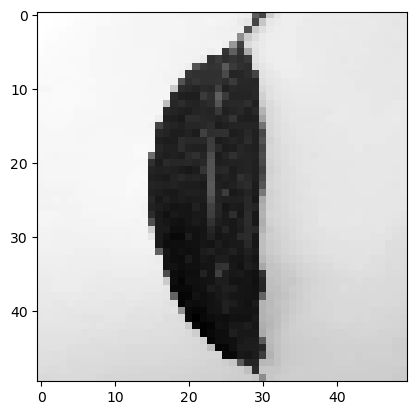

In [38]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (14).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Not Healthy


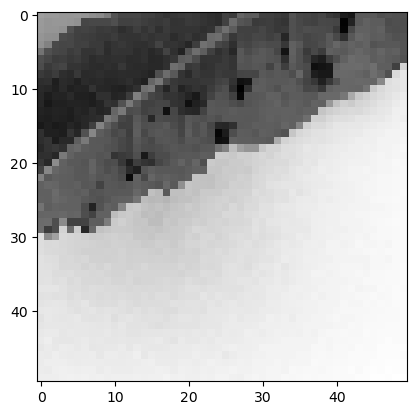

In [39]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (15).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Healthy


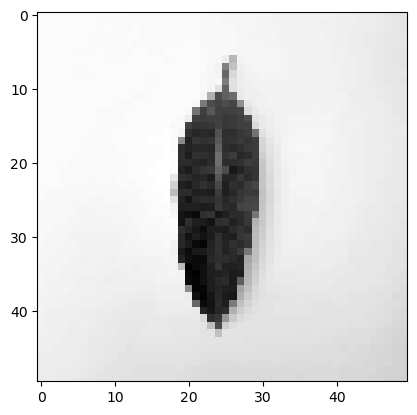

In [40]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (16).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Not Healthy


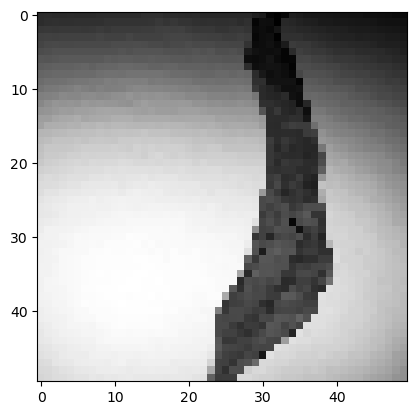

In [41]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (17).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Not Healthy


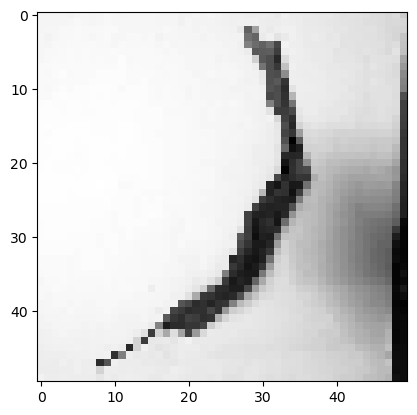

In [42]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (18).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Not Healthy


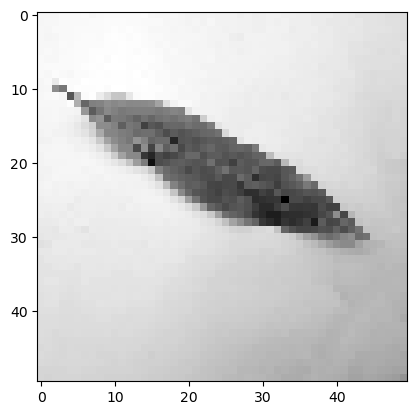

In [43]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (19).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

Prediction is:  Not Healthy


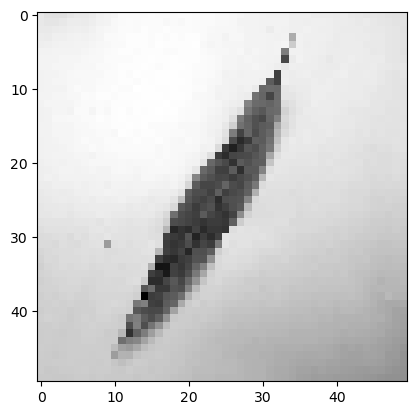

In [44]:
categories = ['Healthy','Not Healthy']
leaf_img = cv2.imread('C:/Users/diyonnah/DS2/G4 Midterm Project/Mango Leaf/Test/Test (20).jpg',0)
leaf_img = cv2.resize(leaf_img,(50,50))
leaf_img = np.array(leaf_img).flatten()
leaf_img = leaf_img.reshape(1, -1)
pred = model.predict(leaf_img)

print('Prediction is: ',categories[pred[0]])
   
mango_leaf = leaf_img.reshape(50,50)
plt.imshow(mango_leaf,cmap='gray')
plt.show()

In [45]:
#saving the model
pick = open('MANGO_LEAF_Classifier.sav','wb')
pickle.dump(model,pick)
pick.close()

In [46]:
#reading the model
pick = open('MANGO_LEAF_Classifier.sav','rb')
model = pickle.load(pick)
pick.close()